In [1]:
import numpy as np, tools_multitracer as mass, pickle, curvedsky as cs, healpy as hp, local
from matplotlib.pyplot import *

In [2]:
import importlib
importlib.reload(mass)

<module 'tools_multitracer' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_multitracer.py'>

In [3]:
lmax = 2*512
L    = np.linspace(0,lmax,lmax+1)
kfac = L*(L+1)/2.
glob  = local.analysis()

In [21]:
Rl = pickle.load(open('/global/cscratch1/sd/lonappan/S4BIRD/DELL_noisefix/s1d1/Reconstruction_190_600/response_fsky_0.80_mean.pkl','rb'))

In [5]:
nl = pickle.load(open('/global/cscratch1/sd/lonappan/S4BIRD/DELL_noisefix/s1d1/Reconstruction_190_600/MCN0_400_fsky_0.80.pkl',"rb"))
print(np.shape(nl))

(1025,)


/tmp/ipykernel_44799/3433977541.py:2: RuntimeWarning: invalid value encountered in true_divide
  loglog(kfac**2*nl/Rl)


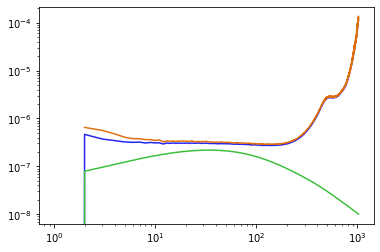

In [22]:
loglog(kfac**2*nl)
loglog(kfac**2*nl/Rl)
loglog(glob.kk[:lmax+1])

In [7]:
Wl = glob.kk[:lmax+1]/(glob.kk[:lmax+1]+nl[:lmax+1]*kfac**2+1e-30)

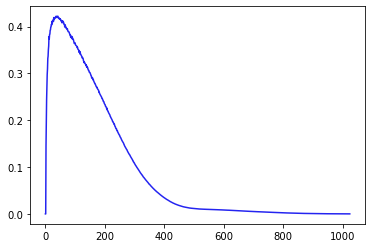

In [8]:
plot(Wl)

In [16]:
Klm = kfac[:,None] * pickle.load(open('/global/cscratch1/sd/lonappan/S4BIRD/DELL_noisefix/s1d1/Reconstruction_190_600/plm/phi_fsky_0.80_0000.pkl',"rb")) 

In [17]:
wKmap = cs.utils.hp_alm2map(512,lmax,lmax,Wl[:,None]*Klm)

In [18]:
iklm  = glob.load_input_kappa(1,lmax)
ikmap = cs.utils.hp_alm2map(512,lmax,lmax,iklm)

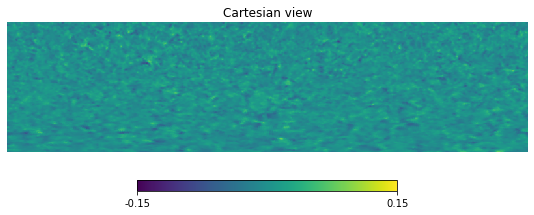

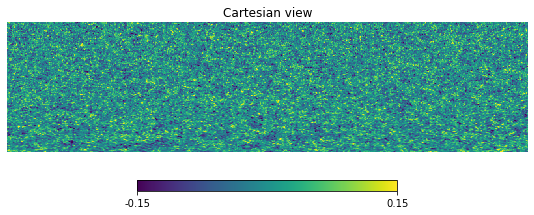

In [19]:
lonra, latra = [-80,80], [-70,-30]
hp.cartview(wKmap,lonra=lonra,latra=latra,min=-.15,max=.15)
hp.cartview(ikmap,lonra=lonra,latra=latra,min=-.15,max=.15)

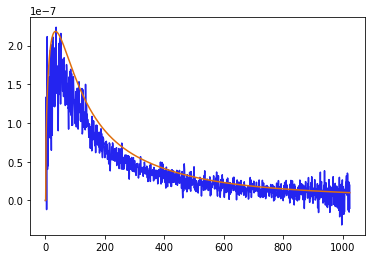

In [20]:
xcl = cs.utils.alm2cl(lmax,Klm,iklm)
plot(xcl)
plot(glob.kk[:lmax+1])